In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.stats import genpareto

In [2]:
# Membaca data dari file Excel
file_path = "sample evt.xlsx"  # Sesuaikan nama file
data = pd.read_excel(file_path, header=0)

In [3]:
# Mengonversi 'Curah Hujan' menjadi numerik
data['Curah Hujan'] = pd.to_numeric(data['Curah Hujan'], errors='coerce')

# Mengonversi 'Tanggal' menjadi format datetime
data['Tanggal'] = pd.to_datetime(data['Tanggal'], errors='coerce')

In [4]:
# Menambahkan kolom 'Bulan' yang terdiri dari Tahun dan Bulan
data['Bulan'] = data['Tanggal'].dt.to_period('M')

# Mengelompokkan berdasarkan bulan dan mencari nilai maksimum dari curah hujan per bulan
bulan_max = data.groupby('Bulan')['Curah Hujan'].max().reset_index()

# Menampilkan tabel baru "Bulan" yang berisi nilai maksimum curah hujan per bulan
print(bulan_max)

      Bulan  Curah Hujan
0   2022-01        117.0
1   2022-02        144.0
2   2022-03         76.5
3   2022-04         32.0
4   2022-05         32.5
5   2022-06         78.0
6   2022-07         40.5
7   2022-08         66.5
8   2022-09         40.5
9   2022-10         58.5
10  2022-11         89.6
11  2022-12        126.4
12  2023-01        130.0
13  2023-02        200.0
14  2023-03        112.5
15  2023-04         45.0
16  2023-05         37.8
17  2023-06         20.0
18  2023-07         66.0
19  2023-08         26.0
20  2023-09         25.5
21  2023-10         39.0
22  2023-11        126.0
23  2023-12         29.5


In [5]:
# 21. Fitting distribusi GEV pada data ekstrem
monthly_extremes = bulan_max['Curah Hujan'].values
params = stats.genextreme.fit(monthly_extremes)  # Fitting distribusi GEV
shape_gev, loc_gev, scale_gev = params  # Parameter distribusi GEV: shape, location, scale
# Menampilkan parameter distribusi GEV
print(f"GEV Parameters - Shape: {shape_gev}, Location: {loc_gev}, Scale: {scale_gev}")

# 22. Menguji kesesuaian distribusi dengan uji Kolmogorov-Smirnov
ks_stat, ks_p_value = stats.kstest(monthly_extremes, 'genextreme', args=params)  # Uji kesesuaian GEV

# 23. Menampilkan hasil uji kesesuaian
print(f"Kolmogorov-Smirnov Test Statistic: {ks_stat}, P-value: {ks_p_value}")

GEV Parameters - Shape: -0.4731722913830413, Location: 44.9885312677102, Scale: 25.517996151905685
Kolmogorov-Smirnov Test Statistic: 0.12704946500223757, P-value: 0.7879239671894843


In [6]:
# Membagi data bulanan (blok) dan menguji distribusi GEV
for month, month_data in bulan_max.groupby('Bulan')['Curah Hujan']:
    # Fitting distribusi GEV untuk setiap bulan
    params_month = stats.genextreme.fit(month_data)
    shape_month, loc_month, scale_month = params_month
    
    # Uji Kolmogorov-Smirnov untuk distribusi GEV setiap bulan
    ks_stat_month, ks_p_value_month = stats.kstest(month_data, 'genextreme', args=params_month)

    # Menampilkan hasil uji kesesuaian GEV untuk bulan tertentu
    print(f"Bulan {month} - GEV KS Test - Statistic: {ks_stat_month}, P-value: {ks_p_value_month}")

c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_distn_infrastructure.py:409: RuntimeWarning: invalid value encountered in scalar divide
  return m3 / np.power(m2, 1.5)


Bulan 2022-01 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-02 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-03 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-04 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-05 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-06 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-07 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-08 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-09 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-10 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-11 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-12 - GEV K

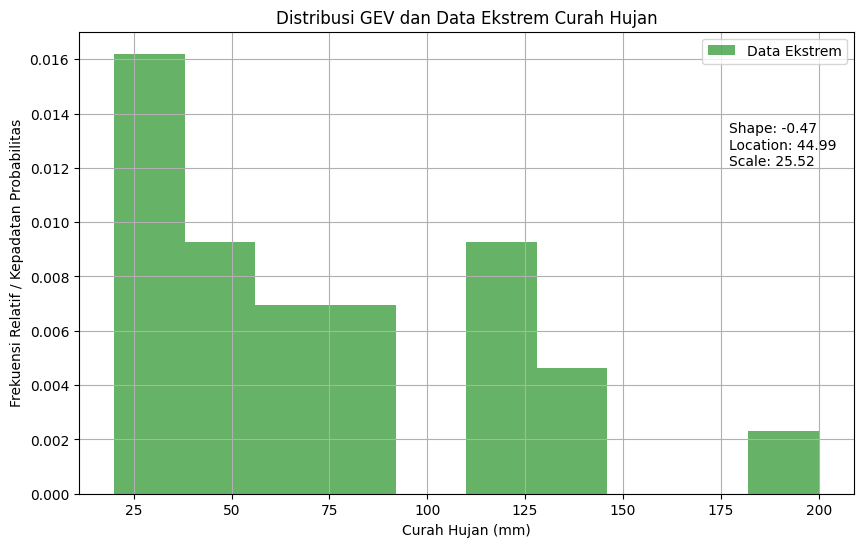

In [7]:
# 24. Plot histogram data ekstrem dan distribusi GEV
plt.figure(figsize=(10, 6))
plt.hist(monthly_extremes, bins=10, density=True, alpha=0.6, color='g', label='Data Ekstrem')


# 26. Plot distribusi GEV
plt.title('Distribusi GEV dan Data Ekstrem Curah Hujan')
plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi Relatif / Kepadatan Probabilitas')
plt.text(177, 0.0121, f'Shape: {shape_gev:.2f}\nLocation: {loc_gev:.2f}\nScale: {scale_gev:.2f}', fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# 30. Fungsi untuk menghitung residual life (rata-rata data yang melebihi threshold)
def calculate_residual_life(threshold, data):
    # Ambil data yang lebih besar dari threshold
    exceedances = data[data > threshold]
    
    # Jika ada data yang melebihi threshold, hitung rata-rata residual life
    if len(exceedances) > 0:
        residual_life = np.mean(exceedances - threshold)  # Rata-rata data yang melebihi threshold
    else:
        residual_life = np.nan  # Jika tidak ada data yang melebihi threshold, beri NaN
    
    return residual_life

In [9]:
# 31. Tentukan rentang threshold yang ingin diuji
thresholds = np.linspace(min(monthly_extremes), max(monthly_extremes), 100)  # Membuat rentang threshold

residual_life_values = [calculate_residual_life(threshold, monthly_extremes) for threshold in thresholds]

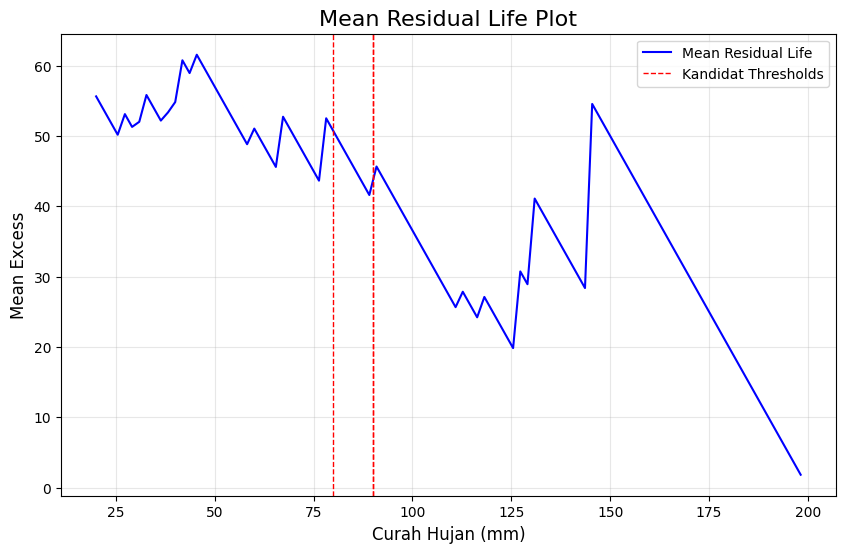

In [10]:
# Membuat plot residual life
plt.figure(figsize=(10, 6))
plt.plot(thresholds, residual_life_values, label="Mean Residual Life", color='blue')

thresholds_lines = [80, 90]
for threshold in thresholds_lines:
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Kandidat Thresholds')
# Menambahkan judul dan label
plt.title('Mean Residual Life Plot', fontsize=16)
plt.xlabel('Curah Hujan (mm)', fontsize=12)
plt.ylabel('Mean Excess', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [11]:
# 38. Threshold yang sudah ditentukan (110 mm)
threshold = 90  # Menentukan threshold untuk data ekstrem

# 39. Identifikasi nilai ekstrem yang lebih besar dari threshold
extreme_values = monthly_extremes[monthly_extremes > threshold]  # Mengambil data yang melebihi threshold

# 40. Menampilkan jumlah nilai ekstrem yang teridentifikasi
print(f"Jumlah nilai ekstrem (lebih besar dari threshold {threshold} mm): {len(extreme_values)}")  # Menampilkan jumlah nilai ekstrem
n_u = len(extreme_values)  # Jumlah nilai ekstrem
n = len(monthly_extremes)  # Jumlah total data

Jumlah nilai ekstrem (lebih besar dari threshold 90 mm): 7


In [12]:
# 41. Fitting distribusi Generalized Pareto Distribution (GPD) pada nilai ekstrem
params_gpd = stats.genpareto.fit(extreme_values)  # Fitting distribusi GPD pada data ekstrem
shape_gpd, loc_gpd, scale_gpd = params_gpd  # Menyimpan parameter distribusi GPD
loc_gpd = 90  # Menetapkan lokasi GPD sesuai threshold
# 42. Menampilkan parameter distribusi GPD
print(f"GPD Parameters - Shape: {shape_gpd}, Location: {loc_gpd}, Scale: {scale_gpd}")  # Menampilkan parameter GPD
# Uji Kolmogorov-Smirnov untuk distribusi GPD pada data ekstrem
ks_stat_gpd, ks_p_value_gpd = stats.kstest(extreme_values, 'genpareto', args=params_gpd)

# Menampilkan hasil uji kesesuaian GPD
print(f"Kolmogorov-Smirnov Test GPD - Statistic: {ks_stat_gpd}, P-value: {ks_p_value_gpd}")

GPD Parameters - Shape: -1.6307727049619496, Location: 90, Scale: 327.2133086508484
Kolmogorov-Smirnov Test GPD - Statistic: 0.3988506274594383, P-value: 0.16189893989805804


In [13]:
# 40. Fitting distribusi GEV untuk seluruh data ekstrem
params_extreme = stats.genextreme.fit(extreme_values)
shape_extreme, loc_extreme, scale_extreme = params_extreme

# 41. Uji Kolmogorov-Smirnov untuk setiap nilai ekstrem terhadap distribusi GEV
for value in extreme_values:
    ks_stat, ks_p_value = stats.kstest([value], 'genextreme', args=params_extreme)
    print(f"Nilai ekstrem: {value} mm - KS Test - Statistic: {ks_stat}, P-value: {ks_p_value}")

Nilai ekstrem: 117.0 mm - KS Test - Statistic: 0.8089478906832892, P-value: 0.3821042186334216
Nilai ekstrem: 144.0 mm - KS Test - Statistic: 0.7745990885137989, P-value: 0.45080182297240223
Nilai ekstrem: 126.4 mm - KS Test - Statistic: 0.5014610480675818, P-value: 0.9970779038648363
Nilai ekstrem: 130.0 mm - KS Test - Statistic: 0.5843273311025404, P-value: 0.8313453377949191
Nilai ekstrem: 200.0 mm - KS Test - Statistic: 0.9483591336949787, P-value: 0.10328173261004259
Nilai ekstrem: 112.5 mm - KS Test - Statistic: 0.9548412353017574, P-value: 0.0903175293964853
Nilai ekstrem: 126.0 mm - KS Test - Statistic: 0.5089720389184719, P-value: 0.9820559221630563


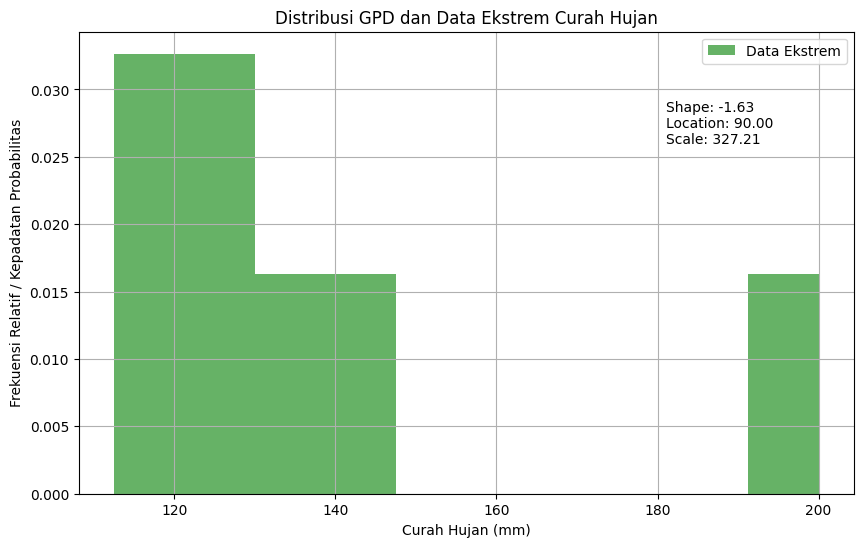

In [14]:
# 44. Plot histogram data ekstrem dan distribusi GPD
plt.figure(figsize=(10, 6))  # Menentukan ukuran plot

# 45. Histogram data ekstrem (gunakan extreme_values, bukan monthly_extremes)
plt.hist(extreme_values, bins=10, density=True, alpha=0.6, color='g', label='Data Ekstrem')  # Menampilkan histogram data ekstrem

# 46. Menambahkan label dan judul pada grafik
plt.title('Distribusi GPD dan Data Ekstrem Curah Hujan')  # Judul grafik
plt.xlabel('Curah Hujan (mm)')  # Label sumbu X
plt.ylabel('Frekuensi Relatif / Kepadatan Probabilitas')  # Label sumbu Y
plt.text(181, 0.026, f'Shape: {shape_gpd:.2f}\nLocation: {loc_gpd:.2f}\nScale: {scale_gpd:.2f}', fontsize=10)
plt.legend()  # Menambahkan legenda
plt.grid(True)  # Menambahkan grid
plt.show()  # Menampilkan grafik

In [ ]:
# 27. Fungsi untuk menghitung Value at Risk (VaR)
def calculate_var_gev(p, shape, loc, scale):
    # Menghitung VaR berdasarkan distribusi GEV atau GPD
    var = loc + (scale / shape) * ((-np.log(1 - p)) ** (shape) - 1)
    return var

def calculate_var_gpd(p, loc, scale, shape, n, n_u):
    # Menghitung VaR berdasarkan distribusi GPD
    x = (n / n_u) * (p)  # Penyesuaian untuk proporsi
    var = loc + (scale / shape) * ((x ** (shape)) - 1)
    return var


In [16]:
# 28. Menghitung VaR untuk masing-masing tingkat kepercayaan
confidence_levels = [0.90, 0.95, 0.99]

var_values_gev = []
for p in confidence_levels:
    var_gev = calculate_var_gev(p, shape_gev, loc_gev, scale_gev)
    var_values_gev.append(var_gev)
    print(f"VaR pada {int(p*100)}% kepercayaan dengan GEV: {var_gev}")

VaR pada 90% kepercayaan dengan GEV: 18.894611914655602
VaR pada 95% kepercayaan dengan GEV: 8.283277074405483
VaR pada 99% kepercayaan dengan GEV: -12.167199400513702


In [17]:
print(loc_gpd)
print(n_u)
print(n)
print(shape_gpd)
print(scale_gpd)

90
7
24
-1.6307727049619496
327.2133086508484


In [18]:
var_values_gpd = []
for p in confidence_levels:
    var_gpd = calculate_var_gpd(p, loc_gpd, scale_gpd, shape_gpd, n, n_u)
    var_values_gpd.append(var_gpd)
    print(f"VaR pada {int(p * 100)}% kepercayaan dengan GPD: {var_gpd}")

VaR pada 90% kepercayaan dengan GPD: 258.7037503826779
VaR pada 95% kepercayaan dengan GPD: 261.3998229469254
VaR pada 99% kepercayaan dengan GPD: 263.3023791411796
